# Assignment 04 — Networks
## Visible but Inaccessible: The High Line from 10th Avenue

**Question:** How does access to the High Line change along 10th Avenue when the park itself remains physically close?

I compare straight-line distance from selected street corners to the High Line with walking-network distance to the nearest verified entrance.


## Setup


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from shapely.geometry import Point
from shapely.ops import nearest_points


In [3]:
north, south = 40.7585, 40.7390
east, west = -73.9950, -74.0125

G = ox.graph_from_bbox(
    bbox=(west, south, east, north),
    network_type="walk",
)

nodes, edges = ox.graph_to_gdfs(G)

edges_proj = ox.projection.project_gdf(edges)
nodes_proj = nodes.to_crs(edges_proj.crs)


## High Line


In [4]:
highline = ox.features_from_bbox(
    bbox=(west, south, east, north),
    tags={"leisure": "park"},
)

highline = highline[
    highline["name"].astype(str).str.contains(
        "High Line",
        case=False,
        na=False,
    )
].copy()

highline_proj = highline.to_crs(edges_proj.crs)
highline_geom = highline_proj.geometry.union_all()


## Entrances


In [5]:
official_access_data = [
    {"id": "access_01", "lat": 40.756326, "lon": -74.003568},
    {"id": "access_02", "lat": 40.753434, "lon": -74.003758},
    {"id": "access_03", "lat": 40.752988, "lon": -74.002723},
    {"id": "access_04", "lat": 40.752345, "lon": -74.001993},
    {"id": "access_05", "lat": 40.751101, "lon": -74.002465},
    {"id": "access_06", "lat": 40.749848, "lon": -74.003378},
    {"id": "access_07", "lat": 40.747970, "lon": -74.004783},
    {"id": "access_09", "lat": 40.744912, "lon": -74.006872},
    {"id": "access_10", "lat": 40.743458, "lon": -74.007215},
    {"id": "access_11", "lat": 40.742014, "lon": -74.007805},
    {"id": "access_12", "lat": 40.739490, "lon": -74.008251},
]

official_access = gpd.GeoDataFrame(
    official_access_data,
    geometry=[
        Point(d["lon"], d["lat"])
        for d in official_access_data
    ],
    crs="EPSG:4326",
)

official_access_proj = official_access.to_crs(edges_proj.crs)


## Observation Points


In [6]:
def name_matches(value, aliases):
    if value is None:
        return False

    if isinstance(value, (list, tuple, np.ndarray)):
        names = [str(v).lower() for v in value if v is not None]
    else:
        names = [str(value).lower()]

    aliases = [a.lower() for a in aliases]

    return any(
        alias in name
        for name in names
        for alias in aliases
    )


In [7]:
street_observations = [
    ("W 18th St", ["West 18th Street", "W 18th St"]),
    ("W 19th St", ["West 19th Street", "W 19th St"]),
    ("W 20th St", ["West 20th Street", "W 20th St"]),
    ("W 21st St", ["West 21st Street", "W 21st St"]),
    ("W 22nd St", ["West 22nd Street", "W 22nd St"]),
    ("W 23rd St", ["West 23rd Street", "W 23rd St"]),
    ("W 24th St", ["West 24th Street", "W 24th St"]),
]

tenth_edges = edges_proj[
    edges_proj["name"].apply(
        lambda x: name_matches(
            x,
            ["10th Avenue", "Tenth Avenue", "10th Ave"],
        )
    )
].copy()

tenth_geom = tenth_edges.geometry.union_all()


In [8]:
records = []

for label, aliases in street_observations:
    street_edges = edges_proj[
        edges_proj["name"].apply(
            lambda x: name_matches(x, aliases)
        )
    ].copy()

    if street_edges.empty:
        continue

    street_geom = street_edges.geometry.union_all()
    p_street, p_tenth = nearest_points(
        street_geom,
        tenth_geom,
    )

    point = Point(
        (p_street.x + p_tenth.x) / 2,
        (p_street.y + p_tenth.y) / 2,
    )

    nearest_highline = nearest_points(
        point,
        highline_geom,
    )[1]

    records.append({
        "street": label,
        "geometry": point,
        "euclidean_to_highline_m": point.distance(nearest_highline),
    })

observations_proj = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs=edges_proj.crs,
)

observations = observations_proj.to_crs("EPSG:4326")


## Network Nodes


In [9]:
observations["origin_node"] = observations.apply(
    lambda row: ox.distance.nearest_nodes(
        G,
        X=row.geometry.x,
        Y=row.geometry.y,
    ),
    axis=1,
)

official_access["access_node"] = official_access.apply(
    lambda row: ox.distance.nearest_nodes(
        G,
        X=row.geometry.x,
        Y=row.geometry.y,
    ),
    axis=1,
)


## Shortest Routes


In [10]:
def find_nearest_entrance_route(row):
    best_distance = np.inf
    best_access_id = None
    best_access_node = None
    best_route = None

    for _, access in official_access.iterrows():
        route = ox.shortest_path(
            G,
            orig=row["origin_node"],
            dest=access["access_node"],
            weight="length",
        )

        if route is None:
            continue

        distance_m = ox.routing.route_to_gdf(
            G,
            route,
        )["length"].sum()

        if distance_m < best_distance:
            best_distance = distance_m
            best_access_id = access["id"]
            best_access_node = access["access_node"]
            best_route = route

    return pd.Series({
        "nearest_access_id": best_access_id,
        "nearest_access_node": best_access_node,
        "network_distance_m": best_distance,
        "route": best_route,
    })


In [11]:
route_results = observations.apply(
    find_nearest_entrance_route,
    axis=1,
)

observations[
    [
        "nearest_access_id",
        "nearest_access_node",
        "network_distance_m",
        "route",
    ]
] = route_results

observations[
    ["street", "nearest_access_id", "network_distance_m"]
]


,street,nearest_access_id,network_distance_m
0,W 18th St,access_09,33.669491
1,W 19th St,access_09,107.383048
2,W 20th St,access_09,181.535127
3,W 21st St,access_07,237.114492
4,W 22nd St,access_07,159.338731
5,W 23rd St,access_07,74.628782
6,W 24th St,access_07,122.540670


## Route Map


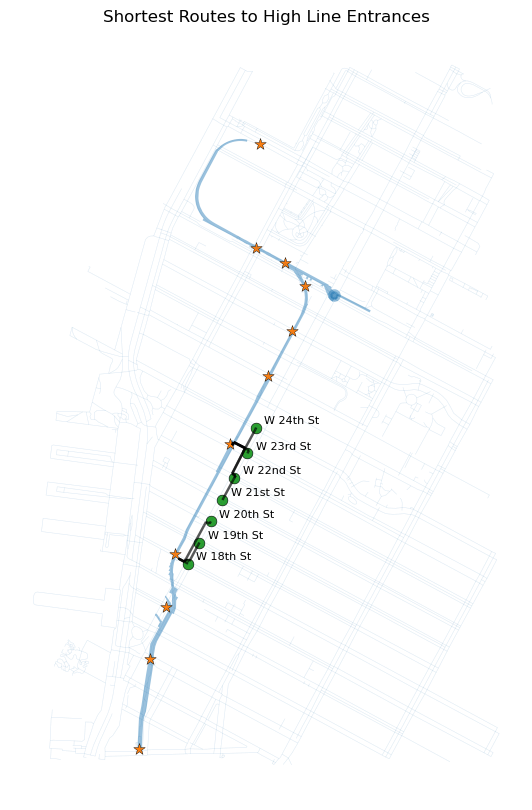

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))

edges_proj.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.08,
)

highline_proj.plot(
    ax=ax,
    linewidth=3,
    alpha=0.45,
)

official_access_proj.plot(
    ax=ax,
    marker="*",
    markersize=75,
    edgecolor="black",
    linewidth=0.3,
)

for _, row in observations.iterrows():
    if row["route"] is None:
        continue

    route_edges = ox.routing.route_to_gdf(
        G,
        row["route"],
    ).to_crs(edges_proj.crs)

    route_edges.plot(
        ax=ax,
        color="black",
        linewidth=1.8,
        alpha=0.65,
    )

observations_proj.plot(
    ax=ax,
    markersize=60,
    edgecolor="black",
    linewidth=0.4,
)

for _, row in observations_proj.iterrows():
    ax.annotate(
        row["street"],
        (row.geometry.x, row.geometry.y),
        xytext=(6, 3),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Shortest Routes to High Line Entrances")
ax.set_axis_off()

plt.show()


## Distance Comparison


In [13]:
comparison = observations_proj[
    ["street", "euclidean_to_highline_m"]
].copy()

comparison["network_distance_m"] = (
    observations["network_distance_m"].values
)

comparison


,street,euclidean_to_highline_m,network_distance_m
0,W 18th St,41.901815,33.669491
1,W 19th St,43.404637,107.383048
2,W 20th St,47.053119,181.535127
3,W 21st St,47.426862,237.114492
4,W 22nd St,47.422222,159.338731
5,W 23rd St,47.078915,74.628782
6,W 24th St,32.678798,122.540670


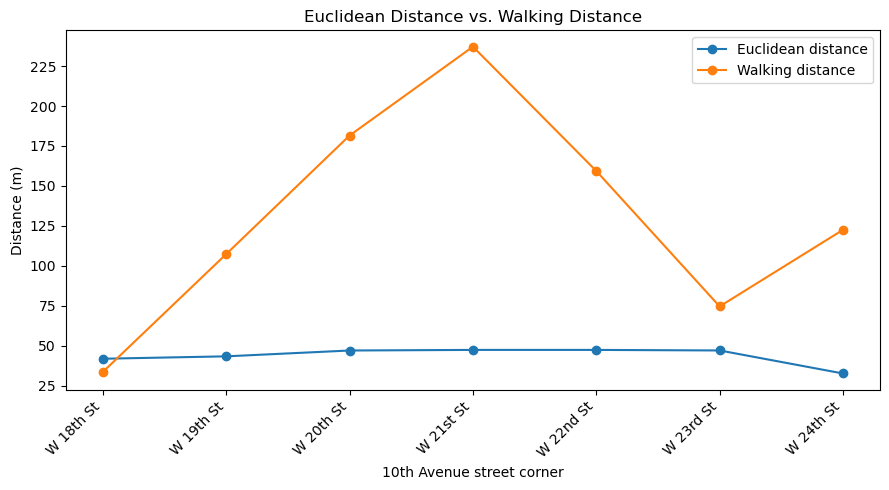

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    comparison["street"],
    comparison["euclidean_to_highline_m"],
    marker="o",
    label="Euclidean distance",
)

ax.plot(
    comparison["street"],
    comparison["network_distance_m"],
    marker="o",
    label="Walking distance",
)

ax.set_xlabel("10th Avenue street corner")
ax.set_ylabel("Distance (m)")
ax.set_title("Euclidean Distance vs. Walking Distance")
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Reflection

Along this section of 10th Avenue, the High Line remains physically close, but access changes from street to street. Straight-line distance stays relatively similar, while walking distance rises and falls with the location of entrances.

The nearest visible part of the High Line is not always a place where a pedestrian can enter it. In this case, network distance describes access more clearly than Euclidean distance.

This comparison only measures horizontal walking distance. Stairs, elevators, closures, and mobility constraints could increase the difference further.
